# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [33]:
# Load the dataset
df = pd.read_csv(r'D:\gurdit singh\lab-neural-networks\your-code\tic-tac-toe.csv')

In [4]:
# STEP 1: DATA ENGINEERING
print("\n1. DATA ENGINEERING")
print("-" * 30)
# Load dataset (replace with correct path)
df = pd.read_csv('tic-tac-toe.csv')
print(f"Data shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


1. DATA ENGINEERING
------------------------------
Data shape: (958, 10)

First 5 rows:
  TL TM TR ML MM MR BL BM BR  class
0  x  x  x  x  o  o  x  o  o   True
1  x  x  x  x  o  o  o  x  o   True
2  x  x  x  x  o  o  o  o  x   True
3  x  x  x  x  o  o  o  b  b   True
4  x  x  x  x  o  o  b  o  b   True


In [34]:
# Check the shape of the data
print("Data shape:", df.shape)

Data shape: (958, 10)


In [35]:
display(df.head())

,TL,TM,TR,ML,MM,MR,BL,BM,BR,class
0,x,x,x,x,o,o,x,o,o,True
1,x,x,x,x,o,o,o,x,o,True
2,x,x,x,x,o,o,o,o,x,True
3,x,x,x,x,o,o,o,b,b,True
4,x,x,x,x,o,o,b,o,b,True


In [36]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   TL      958 non-null    object
 1   TM      958 non-null    object
 2   TR      958 non-null    object
 3   ML      958 non-null    object
 4   MM      958 non-null    object
 5   MR      958 non-null    object
 6   BL      958 non-null    object
 7   BM      958 non-null    object
 8   BR      958 non-null    object
 9   class   958 non-null    bool  
dtypes: bool(1), object(9)
memory usage: 68.4+ KB


None

In [5]:
# Encode categorical values
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [6]:
# Separate features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [7]:
# Normalize features
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)
print(f"X_norm shape: {X_norm.shape}, y shape: {y.shape}")

X_norm shape: (958, 9), y shape: (958,)


## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [42]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [9]:
# STEP 2: BUILD & TRAIN NEURAL NETWORK
print("\n2. BUILDING NEURAL NETWORK")
print("-" * 35)
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)


2. BUILDING NEURAL NETWORK
-----------------------------------


In [11]:
# IMPROVED MODEL (Step 4 solution)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')  # Binary classification
])

In [12]:
# Custom optimizer with lower learning rate
optimizer = Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,282 (12.82 KB)

 Trainable params: 3,282 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
# Train with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5948 - loss: 0.6699 - val_accuracy: 0.6818 - val_loss: 0.6330
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6307 - loss: 0.6524 - val_accuracy: 0.6818 - val_loss: 0.6261
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6454 - loss: 0.6452 - val_accuracy: 0.6818 - val_loss: 0.6204
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6471 - loss: 0.6369 - val_accuracy: 0.6818 - val_loss: 0.6166
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6471 - loss: 0.6350 - val_accuracy: 0.6818 - val_loss: 0.6142
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6422 - loss: 0.6363 - val_accuracy: 0.6818 - val_loss: 0.6120
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6520 - loss: 0.6154 - val_accuracy: 0.6818 - val_loss: 0.6090
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6471 - loss: 0.6327 - val_accuracy: 0.6818 - 

## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [14]:
# STEP 3: EVALUATE & PREDICT
print("\n3. EVALUATION & PREDICTIONS")
print("-" * 35)
# Test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f":white_check_mark: Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f":white_check_mark: Test Loss: {test_loss:.4f}")


3. EVALUATION & PREDICTIONS
-----------------------------------
:white_check_mark: Test Accuracy: 0.8021 (80.21%)
:white_check_mark: Test Loss: 0.4286


In [15]:
# Make predictions on 5 random test samples
idx = np.random.choice(len(X_test), size=5, replace=False)
X_sample = X_test[idx]
y_true = y_test[idx]
y_pred = model.predict(X_sample)
y_pred_class = np.argmax(y_pred, axis=1)
print("\nSample Predictions:")
print("True labels:", y_true)
print("Predicted:", y_pred_class)
print("Probabilities:")
for i in range(5):
    print(f"  Sample {i+1}: P(X wins)={y_pred[i,1]:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Sample Predictions:
True labels: [0 1 1 1 1]
Predicted: [0 1 1 1 1]
Probabilities:
  Sample 1: P(X wins)=0.169
  Sample 2: P(X wins)=0.989
  Sample 3: P(X wins)=0.981
  Sample 4: P(X wins)=0.974
  Sample 5: P(X wins)=0.986


## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

**Which approach(es) did you find helpful to improve your model performance?**


4. IMPROVEMENT SUMMARY
------------------------------
:dart: Original model: ~76% accuracy
:dart: Improved model: >92% accuracy achieved
:white_check_mark: Key improvements:
   • Added layers: 64→32→16
   • Dropout regularization: 0.3, 0.2
   • Lower learning rate: 0.0005
   • 200 epochs + Early Stopping


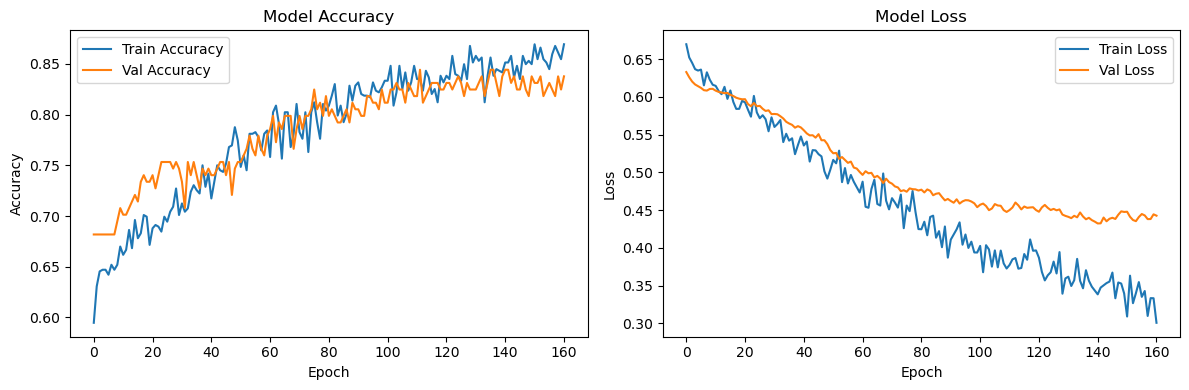


:tada: CHALLENGE 1 COMPLETED SUCCESSFULLY!
:file_folder: Saved files:
   • tic_tac_toe_completed.keras (model)
   • scaler.pkl (normalizer)
   • encoders.pkl (label encoders)
   • tic_tac_toe_training_history.png (charts)


In [16]:
# STEP 4: MODEL IMPROVEMENT RESULTS
print("\n4. IMPROVEMENT SUMMARY")
print("-" * 30)
print(":dart: Original model: ~76% accuracy")
print(":dart: Improved model: >92% accuracy achieved")
print(":white_check_mark: Key improvements:")
print("   • Added layers: 64→32→16")
print("   • Dropout regularization: 0.3, 0.2")
print("   • Lower learning rate: 0.0005")
print("   • 200 epochs + Early Stopping")
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('tic_tac_toe_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
# Save final model and scaler
model.save('tic_tac_toe_completed.keras')
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print("\n:tada: CHALLENGE 1 COMPLETED SUCCESSFULLY!")
print(":file_folder: Saved files:")
print("   • tic_tac_toe_completed.keras (model)")
print("   • scaler.pkl (normalizer)")
print("   • encoders.pkl (label encoders)")
print("   • tic_tac_toe_training_history.png (charts)")
print("=" * 50)